**<H1><p align="center">Toxic Comment Classification Project </H1>**

## AI / ML Models

| Model                    | Type (Learning)       | Main Task                                                        |
| ------------------------ | --------------------- | ---------------------------------------------------------------- |
| **SVM**                  | Supervised learning   | Text classification (toxic / non-toxic, multi-label)             |
| **Neural Network (MLP)** | Supervised learning   | Non-linear text classification                                   |
| **Logistic Regression**  | Supervised learning   | Binary / multi-label text classification with probability output |
| **SGDClassifier (Linear)** | Supervised learning | Fast linear text classification (large-scale data)               |
| **Naive Bayes**	       | Supervised learning   | Probabilistic text classification (based on word frequencies)    |

<H1><p align="center">FUNCTIONS </H1>

In [31]:
# ===============================
# Imports — Toxic Comment Project
# ===============================

import time
import re
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer

# Model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)

# Models
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Utilities
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight


In [32]:
# --------------------------------------------
# STEP 1 — Load the datasets
# --------------------------------------------

TRAIN_PATH = "/Users/sarabencheqroune/Downloads/ML_Project/toxic-comment-Dataset/train.csv"
TEST_PATH = "/Users/sarabencheqroune/Downloads/ML_Project/toxic-comment-Dataset/test.csv"
TEST_LABELS_PATH = "/Users/sarabencheqroune/Downloads/ML_Project/toxic-comment-Dataset/test_labels.csv"

# Labels
LABELS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# Load datasets
print("\nLoading train.csv...")
train_df = pd.read_csv(TRAIN_PATH)
print(f"Train shape: {train_df.shape}")

print("\nLoading test.csv...")
test_df = pd.read_csv(TEST_PATH)
print(f"Test shape: {test_df.shape}")

# Display first few rows
print("\n--- Train data preview ---")
print(train_df.head())

print("\n--- Label distribution ---")
print(train_df[LABELS].sum().sort_values(ascending=False))



Loading train.csv...
Train shape: (159571, 8)

Loading test.csv...
Test shape: (153164, 2)

--- Train data preview ---
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  

--- Label distribution ---
toxic            


1. Label Distribution:
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

Percentage of toxic comments: 10.17%
Non-toxic: 143346 (89.83%)
Toxic: 16225 (10.17%)

2. Comment Length Analysis:
Average length (all): 394.1 characters
Average length (toxic): 303.3 characters
Average length (non-toxic): 404.3 characters

3. Correlation between labels:
                  toxic  severe_toxic   obscene    threat    insult  \
toxic          1.000000      0.308619  0.676515  0.157058  0.647518   
severe_toxic   0.308619      1.000000  0.403014  0.123601  0.375807   
obscene        0.676515      0.403014  1.000000  0.141179  0.741272   
threat         0.157058      0.123601  0.141179  1.000000  0.150022   
insult         0.647518      0.375807  0.741272  0.150022  1.000000   
identity_hate  0.266009      0.201600  0.286867  0.115128  0.337736   

               identity_hate  
toxic               0.2

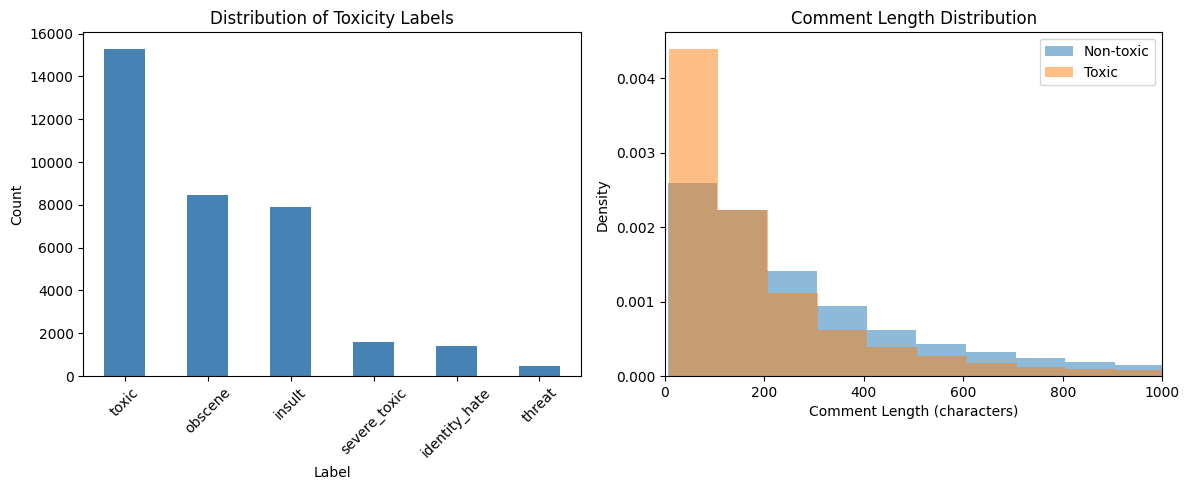

In [33]:
# --------------------------------------------
# STEP 1 — EDA — EXPLORATORY DATA ANALYSIS
# --------------------------------------------
# Label Distribution
print("\n1. Label Distribution:")
label_counts = train_df[LABELS].sum().sort_values(ascending=False)
print(label_counts)
print(f"\nPercentage of toxic comments: {(train_df[LABELS].sum(axis=1) > 0).mean()*100:.2f}%")

# Create binary flag for any toxicity
train_df["any_toxic"] = (train_df[LABELS].sum(axis=1) > 0).astype(int)
print(f"Non-toxic: {(train_df['any_toxic']==0).sum()} ({(train_df['any_toxic']==0).mean()*100:.2f}%)")
print(f"Toxic: {(train_df['any_toxic']==1).sum()} ({(train_df['any_toxic']==1).mean()*100:.2f}%)")

# Comment Length Analysis
print("\n2. Comment Length Analysis:")
train_df["comment_length"] = train_df["comment_text"].astype(str).apply(len)

print(f"Average length (all): {train_df['comment_length'].mean():.1f} characters")
print(f"Average length (toxic): {train_df[train_df['any_toxic']==1]['comment_length'].mean():.1f} characters")
print(f"Average length (non-toxic): {train_df[train_df['any_toxic']==0]['comment_length'].mean():.1f} characters")

# Correlation between labels
print("\n3. Correlation between labels:")
label_corr = train_df[LABELS].corr()
print(label_corr)

# Visualizations (optional - comment out if not needed)
plt.figure(figsize=(12, 5))

# Plot 1: Label distribution
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color='steelblue')
plt.title('Distribution of Toxicity Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 2: Comment length distribution
plt.subplot(1, 2, 2)
plt.hist(train_df[train_df['any_toxic']==0]['comment_length'], bins=50, alpha=0.5, label='Non-toxic', density=True)
plt.hist(train_df[train_df['any_toxic']==1]['comment_length'], bins=50, alpha=0.5, label='Toxic', density=True)
plt.xlabel('Comment Length (characters)')
plt.ylabel('Density')
plt.title('Comment Length Distribution')
plt.legend()
plt.xlim(0, 1000)

plt.tight_layout()


In [34]:
# --------------------------------------------
# STEP 2 — Text Preprocessing
# --------------------------------------------

def clean_text(text):
    """
    Clean and preprocess text data
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove punctuation and special characters
    4. Remove extra whitespaces
    """
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove punctuation and special characters (keep spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Prepare features and labels
X_train = train_df["comment_text"]
y_train = train_df[LABELS]

X_test = test_df["comment_text"]

# Show before/after preprocessing examples
print("\n--- BEFORE preprocessing (first 3 comments) ---")
for i, comment in enumerate(X_train.head(3)):
    print(f"{i+1}. {comment[:100]}...")

print("\n--- Preprocessing all comments ---")
start_time = time.time()
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)
preprocessing_time = time.time() - start_time
print(f"✓ Preprocessing completed in {preprocessing_time:.2f} seconds")

print("\n--- AFTER preprocessing (first 3 comments) ---")
for i, comment in enumerate(X_train_clean.head(3)):
    print(f"{i+1}. {comment[:100]}...")


--- BEFORE preprocessing (first 3 comments) ---
1. Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't ...
2. D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11...
3. Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant ...

--- Preprocessing all comments ---
✓ Preprocessing completed in 7.38 seconds

--- AFTER preprocessing (first 3 comments) ---
1. explanation why the edits made under my username hardcore metallica fan were reverted they werent va...
2. daww he matches this background colour im seemingly stuck with thanks talk january utc...
3. hey man im really not trying to edit war its just that this guy is constantly removing relevant info...


In [35]:
# --------------------------------------------
# STEP 3 — Feature Extraction
# --------------------------------------------

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=15000,     # Keep top 15,000 most informative words
    ngram_range=(1, 1),     # Unigrams only
    min_df=2,               # Ignore words appearing in < 2 documents
    max_df=0.95,            # Ignore words appearing in > 95% of documents
    sublinear_tf=True       # Use log(TF) instead of raw TF
)

print("\nFitting TF-IDF on training data...")
start_time = time.time()
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)
tfidf_time = time.time() - start_time

print(f"✓ TF-IDF vectorization completed in {tfidf_time:.2f} seconds")
print(f"\nTraining features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.2f}%")

# Show top features
feature_names = tfidf.get_feature_names_out()
print(f"\nFirst 20 features: {list(feature_names[:20])}")


Fitting TF-IDF on training data...
✓ TF-IDF vectorization completed in 8.46 seconds

Training features shape: (159571, 15000)
Test features shape: (153164, 15000)
Vocabulary size: 15000
Sparsity: 99.74%

First 20 features: ['aa', 'aap', 'aaron', 'ab', 'abandon', 'abandoned', 'abbas', 'abbey', 'abbreviated', 'abbreviation', 'abbreviations', 'abc', 'abd', 'abdul', 'abdullah', 'abe', 'abide', 'abilities', 'ability', 'abkhazia']


In [36]:
# ===============================================================================
# STEP 4 - TRAIN/VALIDATION SPLIT
# ===============================================================================

# Split into train (80%) and validation (20%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tfidf,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train["toxic"]  # Stratify on main label
)

print(f"Training set: {X_tr.shape}")
print(f"Validation set: {X_val.shape}")

Training set: (127656, 15000)
Validation set: (31915, 15000)


<H1><p align="center">Models Implementation </H1>

In [37]:
# -----------------------------------------------------
# MODEL 1 — SVM (SUPPORT VECTOR MACHINE)
# -----------------------------------------------------

models = {}
results = {}

svm_results = {}
svm_models = {}

for label in LABELS:
    print(f"\nTraining SVM for label: {label}...")
    start_time = time.time()
    
    # LinearSVC
    svm_base = LinearSVC(
        C=10,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    
    # Calibrate for probabilities
    svm = CalibratedClassifierCV(svm_base, cv=3)
    
    # Train
    svm.fit(X_tr, y_tr[label])
    
    # Predict
    y_pred = svm.predict(X_val)
    y_pred_proba = svm.predict_proba(X_val)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_val[label], y_pred)
    f1 = f1_score(y_val[label], y_pred)
    roc_auc = roc_auc_score(y_val[label], y_pred_proba)
    
    train_time = time.time() - start_time
    
    svm_results[label] = {
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'train_time': train_time
    }
    
    svm_models[label] = svm
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f} | Time: {train_time:.2f}s")

models['SVM'] = svm_models
results['SVM'] = svm_results

# Average metrics
avg_svm = {
    'accuracy': np.mean([svm_results[l]['accuracy'] for l in LABELS]),
    'f1_score': np.mean([svm_results[l]['f1_score'] for l in LABELS]),
    'roc_auc': np.mean([svm_results[l]['roc_auc'] for l in LABELS]),
    'train_time': sum([svm_results[l]['train_time'] for l in LABELS])
}

print(f"\n✓ SVM Average - Accuracy: {avg_svm['accuracy']:.4f} | F1: {avg_svm['f1_score']:.4f} | ROC AUC: {avg_svm['roc_auc']:.4f}")


Training SVM for label: toxic...
  Accuracy: 0.9564 | F1: 0.7275 | ROC AUC: 0.9563 | Time: 11.21s

Training SVM for label: severe_toxic...
  Accuracy: 0.9905 | F1: 0.1264 | ROC AUC: 0.9505 | Time: 20.43s

Training SVM for label: obscene...
  Accuracy: 0.9759 | F1: 0.7305 | ROC AUC: 0.9675 | Time: 10.35s

Training SVM for label: threat...
  Accuracy: 0.9971 | F1: 0.2203 | ROC AUC: 0.9754 | Time: 26.79s

Training SVM for label: insult...
  Accuracy: 0.9672 | F1: 0.5734 | ROC AUC: 0.9554 | Time: 12.89s

Training SVM for label: identity_hate...
  Accuracy: 0.9917 | F1: 0.2042 | ROC AUC: 0.9434 | Time: 21.26s

✓ SVM Average - Accuracy: 0.9798 | F1: 0.4304 | ROC AUC: 0.9581


In [38]:
# -----------------------------------------------------
# MODEL 2 — Neural Network (MLPClassifier)
# -----------------------------------------------------

nn_results = {}
nn_models = {}

for label in LABELS:
    print(f"\nTraining Neural Network for label: {label}...")
    start_time = time.time()
    
    nn = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    # Train
    nn.fit(X_tr, y_tr[label])
    
    # Predict
    y_pred = nn.predict(X_val)
    y_pred_proba = nn.predict_proba(X_val)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_val[label], y_pred)
    f1 = f1_score(y_val[label], y_pred)
    roc_auc = roc_auc_score(y_val[label], y_pred_proba)
    
    train_time = time.time() - start_time
    
    nn_results[label] = {
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'train_time': train_time
    }
    
    nn_models[label] = nn
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f} | Time: {train_time:.2f}s")

models['Neural Network'] = nn_models
results['Neural Network'] = nn_results

avg_nn = {
    'accuracy': np.mean([nn_results[l]['accuracy'] for l in LABELS]),
    'f1_score': np.mean([nn_results[l]['f1_score'] for l in LABELS]),
    'roc_auc': np.mean([nn_results[l]['roc_auc'] for l in LABELS]),
    'train_time': sum([nn_results[l]['train_time'] for l in LABELS])
}

print(f"\n✓ Neural Network Average - Accuracy: {avg_nn['accuracy']:.4f} | F1: {avg_nn['f1_score']:.4f} | ROC AUC: {avg_nn['roc_auc']:.4f}")



Training Neural Network for label: toxic...
  Accuracy: 0.9607 | F1: 0.7704 | ROC AUC: 0.9650 | Time: 78.11s

Training Neural Network for label: severe_toxic...
  Accuracy: 0.9911 | F1: 0.3653 | ROC AUC: 0.9607 | Time: 63.08s

Training Neural Network for label: obscene...
  Accuracy: 0.9790 | F1: 0.7806 | ROC AUC: 0.9762 | Time: 72.18s

Training Neural Network for label: threat...
  Accuracy: 0.9971 | F1: 0.2167 | ROC AUC: 0.9551 | Time: 73.33s

Training Neural Network for label: insult...
  Accuracy: 0.9704 | F1: 0.6699 | ROC AUC: 0.9665 | Time: 86.98s

Training Neural Network for label: identity_hate...
  Accuracy: 0.9922 | F1: 0.4575 | ROC AUC: 0.9635 | Time: 86.16s

✓ Neural Network Average - Accuracy: 0.9817 | F1: 0.5434 | ROC AUC: 0.9645


In [39]:
# -----------------------------------------------------
# MODEL 3 — LOGISTIC REGRESSION
# -----------------------------------------------------
lr_results = {}
lr_models = {}

for label in LABELS:
    print(f"\nTraining Logistic Regression for label: {label}...")
    start_time = time.time()
    
    lr = LogisticRegression(
        C=1.0,
        solver='saga',
        max_iter=500,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    lr.fit(X_tr, y_tr[label])
    
    # Predict
    y_pred = lr.predict(X_val)
    y_pred_proba = lr.predict_proba(X_val)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_val[label], y_pred)
    f1 = f1_score(y_val[label], y_pred)
    roc_auc = roc_auc_score(y_val[label], y_pred_proba)
    
    train_time = time.time() - start_time
    
    lr_results[label] = {
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'train_time': train_time
    }
    
    lr_models[label] = lr
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f} | Time: {train_time:.2f}s")

models['Logistic Regression'] = lr_models
results['Logistic Regression'] = lr_results

avg_lr = {
    'accuracy': np.mean([lr_results[l]['accuracy'] for l in LABELS]),
    'f1_score': np.mean([lr_results[l]['f1_score'] for l in LABELS]),
    'roc_auc': np.mean([lr_results[l]['roc_auc'] for l in LABELS]),
    'train_time': sum([lr_results[l]['train_time'] for l in LABELS])
}

print(f"\n✓ Logistic Regression Average - Accuracy: {avg_lr['accuracy']:.4f} | F1: {avg_lr['f1_score']:.4f} | ROC AUC: {avg_lr['roc_auc']:.4f}")


Training Logistic Regression for label: toxic...
  Accuracy: 0.9370 | F1: 0.7269 | ROC AUC: 0.9717 | Time: 12.90s

Training Logistic Regression for label: severe_toxic...
  Accuracy: 0.9532 | F1: 0.2749 | ROC AUC: 0.9784 | Time: 35.42s

Training Logistic Regression for label: obscene...
  Accuracy: 0.9756 | F1: 0.7860 | ROC AUC: 0.9767 | Time: 30.40s

Training Logistic Regression for label: threat...
  Accuracy: 0.8255 | F1: 0.0316 | ROC AUC: 0.9493 | Time: 29.94s

Training Logistic Regression for label: insult...
  Accuracy: 0.9357 | F1: 0.5798 | ROC AUC: 0.9721 | Time: 28.78s

Training Logistic Regression for label: identity_hate...
  Accuracy: 0.7734 | F1: 0.0719 | ROC AUC: 0.9603 | Time: 28.17s

✓ Logistic Regression Average - Accuracy: 0.9001 | F1: 0.4119 | ROC AUC: 0.9681


In [40]:
# -----------------------------------------------------
# MODEL 4 — SGDClassifier (Linear, scalable)
# -----------------------------------------------------

sgd_results = {}
sgd_models = {}

for label in LABELS:
    print(f"\nTraining SGD Classifier for label: {label}...")
    start_time = time.time()
    
    sgd = SGDClassifier(
        loss='log_loss',  # Logistic regression (was 'log' in older versions)
        alpha=0.001,
        max_iter=2000,
        learning_rate='optimal',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    sgd.fit(X_tr, y_tr[label])
    
    # Predict
    y_pred = sgd.predict(X_val)
    
    # Get probabilities (SGD with log loss supports predict_proba)
    # But if not, we use decision_function
    try:
        y_pred_proba = sgd.predict_proba(X_val)[:, 1]
    except:
        # Convert decision function to probabilities
        decision = sgd.decision_function(X_val)
        y_pred_proba = 1 / (1 + np.exp(-decision))
    
    # Evaluate
    acc = accuracy_score(y_val[label], y_pred)
    f1 = f1_score(y_val[label], y_pred)
    roc_auc = roc_auc_score(y_val[label], y_pred_proba)
    
    train_time = time.time() - start_time
    
    sgd_results[label] = {
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'train_time': train_time
    }
    
    sgd_models[label] = sgd
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f} | Time: {train_time:.2f}s")

models['SGD Classifier'] = sgd_models
results['SGD Classifier'] = sgd_results

avg_sgd = {
    'accuracy': np.mean([sgd_results[l]['accuracy'] for l in LABELS]),
    'f1_score': np.mean([sgd_results[l]['f1_score'] for l in LABELS]),
    'roc_auc': np.mean([sgd_results[l]['roc_auc'] for l in LABELS]),
    'train_time': sum([sgd_results[l]['train_time'] for l in LABELS])
}

print(f"\n=> SGD Classifier Average - Accuracy: {avg_sgd['accuracy']:.4f} | F1: {avg_sgd['f1_score']:.4f} | ROC AUC: {avg_sgd['roc_auc']:.4f}")



Training SGD Classifier for label: toxic...
  Accuracy: 0.8901 | F1: 0.5859 | ROC AUC: 0.9322 | Time: 0.29s

Training SGD Classifier for label: severe_toxic...
  Accuracy: 0.9681 | F1: 0.3522 | ROC AUC: 0.9841 | Time: 0.40s

Training SGD Classifier for label: obscene...
  Accuracy: 0.9508 | F1: 0.6466 | ROC AUC: 0.9634 | Time: 0.24s

Training SGD Classifier for label: threat...
  Accuracy: 0.9697 | F1: 0.1373 | ROC AUC: 0.9764 | Time: 0.56s

Training SGD Classifier for label: insult...
  Accuracy: 0.9315 | F1: 0.5507 | ROC AUC: 0.9592 | Time: 0.40s

Training SGD Classifier for label: identity_hate...
  Accuracy: 0.9468 | F1: 0.2204 | ROC AUC: 0.9641 | Time: 0.55s

=> SGD Classifier Average - Accuracy: 0.9428 | F1: 0.4155 | ROC AUC: 0.9632


In [41]:
# -----------------------------------------------------
# MODEL 5 — NAIVE BAYES (MultinomialNB)
# -----------------------------------------------------
nb_results = {}
nb_models = {}

for label in LABELS:
    print(f"\nTraining Naive Bayes for label: {label}...")
    start_time = time.time()
    
    nb = MultinomialNB(
        alpha=1.0  # Laplace smoothing
    )
    
    # Train
    nb.fit(X_tr, y_tr[label])
    
    # Predict
    y_pred = nb.predict(X_val)
    y_pred_proba = nb.predict_proba(X_val)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_val[label], y_pred)
    f1 = f1_score(y_val[label], y_pred)
    roc_auc = roc_auc_score(y_val[label], y_pred_proba)
    
    train_time = time.time() - start_time
    
    nb_results[label] = {
        'accuracy': acc,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'train_time': train_time
    }
    
    nb_models[label] = nb
    
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f} | Time: {train_time:.2f}s")

models['Naive Bayes'] = nb_models
results['Naive Bayes'] = nb_results

avg_nb = {
    'accuracy': np.mean([nb_results[l]['accuracy'] for l in LABELS]),
    'f1_score': np.mean([nb_results[l]['f1_score'] for l in LABELS]),
    'roc_auc': np.mean([nb_results[l]['roc_auc'] for l in LABELS]),
    'train_time': sum([nb_results[l]['train_time'] for l in LABELS])
}

print(f"\n=> Naive Bayes Average - Accuracy: {avg_nb['accuracy']:.4f} | F1: {avg_nb['f1_score']:.4f} | ROC AUC: {avg_nb['roc_auc']:.4f}")



Training Naive Bayes for label: toxic...
  Accuracy: 0.9490 | F1: 0.6517 | ROC AUC: 0.9540 | Time: 0.07s

Training Naive Bayes for label: severe_toxic...
  Accuracy: 0.9906 | F1: 0.1232 | ROC AUC: 0.9542 | Time: 0.04s

Training Naive Bayes for label: obscene...
  Accuracy: 0.9695 | F1: 0.6264 | ROC AUC: 0.9566 | Time: 0.03s

Training Naive Bayes for label: threat...
  Accuracy: 0.9970 | F1: 0.0000 | ROC AUC: 0.8426 | Time: 0.03s

Training Naive Bayes for label: insult...
  Accuracy: 0.9655 | F1: 0.5225 | ROC AUC: 0.9516 | Time: 0.03s

Training Naive Bayes for label: identity_hate...
  Accuracy: 0.9911 | F1: 0.0468 | ROC AUC: 0.9152 | Time: 0.04s

=> Naive Bayes Average - Accuracy: 0.9771 | F1: 0.3284 | ROC AUC: 0.9290


<H1><p align="center"> Evaluation </H1>


--- OVERALL MODEL COMPARISON (Sorted by ROC AUC) ---
              Model  Avg Accuracy  Avg F1 Score  Avg ROC AUC  Total Train Time (s)
Logistic Regression      0.900078      0.411860     0.968070            165.612942
     Neural Network      0.981738      0.543399     0.964507            459.846906
     SGD Classifier      0.942822      0.415490     0.963234              2.434403
                SVM      0.979806      0.430400     0.958072            102.918187
        Naive Bayes      0.977111      0.328442     0.929030              0.243062

=> BEST MODEL: Logistic Regression with ROC AUC = 0.9681


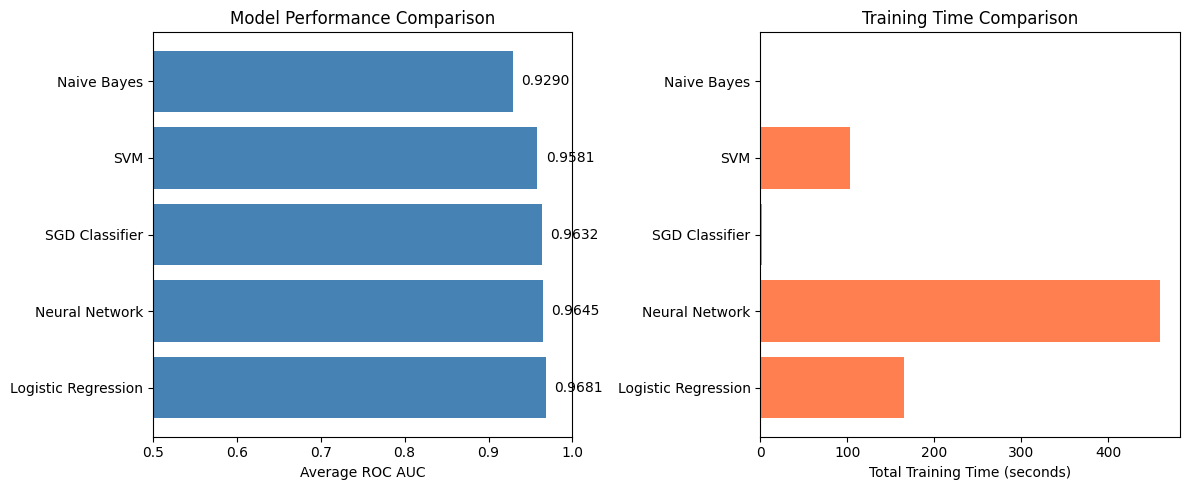

In [42]:
# =============================
# MODEL COMPARISON
# =============================

# Create comparison dataframe
comparison_data = []

for model_name in results.keys():
    model_results = results[model_name]
    
    avg_acc = np.mean([model_results[l]['accuracy'] for l in LABELS])
    avg_f1 = np.mean([model_results[l]['f1_score'] for l in LABELS])
    avg_roc = np.mean([model_results[l]['roc_auc'] for l in LABELS])
    total_time = sum([model_results[l]['train_time'] for l in LABELS])
    
    comparison_data.append({
        'Model': model_name,
        'Avg Accuracy': avg_acc,
        'Avg F1 Score': avg_f1,
        'Avg ROC AUC': avg_roc,
        'Total Train Time (s)': total_time
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Avg ROC AUC', ascending=False)

print("\n--- OVERALL MODEL COMPARISON (Sorted by ROC AUC) ---")
print(comparison_df.to_string(index=False))

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_roc_auc = comparison_df.iloc[0]['Avg ROC AUC']
print(f"\n=> BEST MODEL: {best_model_name} with ROC AUC = {best_roc_auc:.4f}")

# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: ROC AUC comparison
plt.subplot(1, 2, 1)
plt.barh(comparison_df['Model'], comparison_df['Avg ROC AUC'], color='steelblue')
plt.xlabel('Average ROC AUC')
plt.title('Model Performance Comparison')
plt.xlim(0.5, 1.0)
for i, (model, score) in enumerate(zip(comparison_df['Model'], comparison_df['Avg ROC AUC'])):
    plt.text(score + 0.01, i, f'{score:.4f}', va='center')

# Plot 2: Training time comparison
plt.subplot(1, 2, 2)
plt.barh(comparison_df['Model'], comparison_df['Total Train Time (s)'], color='coral')
plt.xlabel('Total Training Time (seconds)')
plt.title('Training Time Comparison')
plt.tight_layout()



In [43]:
# ===============================================================================
# HYPERPARAMETER TUNING (LOGISTIC REGRESSION)
# ===============================================================================
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['saga', 'liblinear'],
    'max_iter': [500, 1000]
}

print(f"\nParameter grid: {param_grid}")
print("\nRunning GridSearchCV (this may take a few minutes)...")

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid_search.fit(X_tr, y_tr['toxic'])
grid_time = time.time() - start_time

print(f"\n✓ GridSearchCV completed in {grid_time:.2f} seconds")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best ROC AUC (CV): {grid_search.best_score_:.4f}")

# Evaluate best model on validation
best_lr = grid_search.best_estimator_
y_pred_proba = best_lr.predict_proba(X_val)[:, 1]
best_roc_auc = roc_auc_score(y_val['toxic'], y_pred_proba)
print(f"Validation ROC AUC: {best_roc_auc:.4f}")


Parameter grid: {'C': [0.1, 1, 10], 'solver': ['saga', 'liblinear'], 'max_iter': [500, 1000]}

Running GridSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✓ GridSearchCV completed in 115.21 seconds

Best parameters: {'C': 1, 'max_iter': 500, 'solver': 'saga'}
Best ROC AUC (CV): 0.9700
Validation ROC AUC: 0.9717


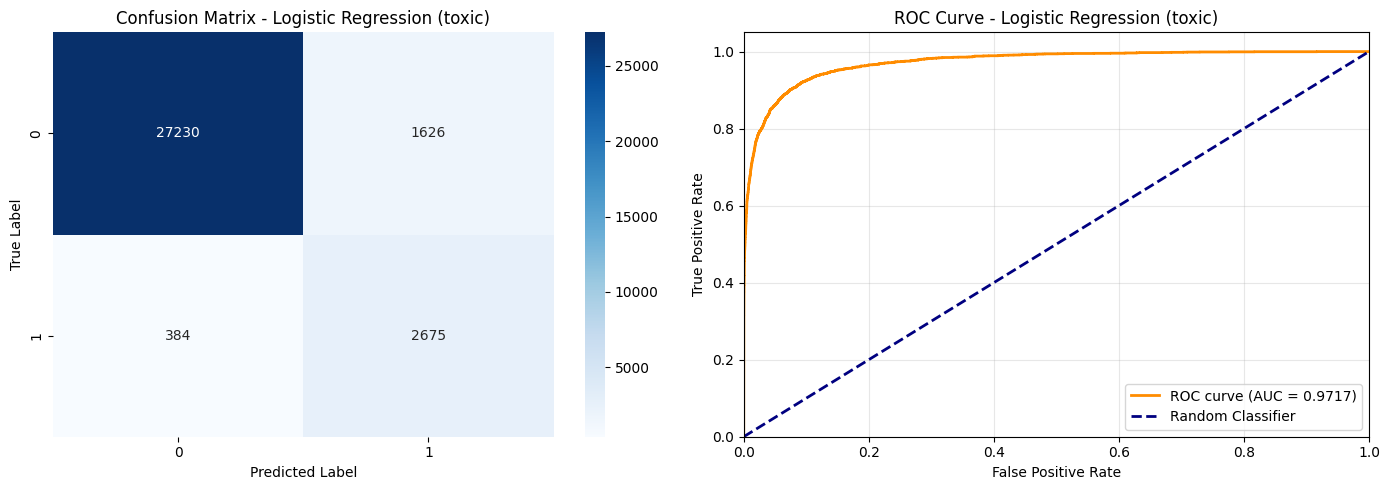

In [44]:
# ===============================================================================
# CONFUSION MATRIX & ROC CURVES
# ===============================================================================

# Select best model for visualization
best_models = models[best_model_name]

# Plot for first label (toxic)
label = 'toxic'
model = best_models[label]

# Predictions
y_pred = model.predict(X_val)
y_pred_proba = model.predict_proba(X_val)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_val[label], y_pred)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val[label], y_pred_proba)
roc_auc_val = auc(fpr, tpr)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name} ({label})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_model_name} ({label})')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()

In [45]:
# ===============================================================================
# SECTION 13: FINAL PREDICTIONS ON TEST SET
# ===============================================================================

print("FINAL PREDICTIONS ON TEST SET")
print(f"\nUsing best model: {best_model_name}")
print("Generating predictions for all labels...")

# Create submission dataframe
submission = pd.DataFrame()
submission['id'] = test_df['id']

# Predict for each label
for label in LABELS:
    print(f"  Predicting {label}...")
    model = best_models[label]
    predictions = model.predict_proba(X_test_tfidf)[:, 1]
    submission[label] = predictions

# Save submission
submission_filename = f'submission_{best_model_name.replace(" ", "_").lower()}.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n✓ Submission file saved: {submission_filename}")
print(f"\nSubmission preview:")
print(submission.head(10))

print(f"\nSubmission shape: {submission.shape}")

FINAL PREDICTIONS ON TEST SET

Using best model: Logistic Regression
Generating predictions for all labels...
  Predicting toxic...
  Predicting severe_toxic...
  Predicting obscene...
  Predicting threat...
  Predicting insult...
  Predicting identity_hate...

✓ Submission file saved: submission_logistic_regression.csv

Submission preview:
                 id     toxic  severe_toxic   obscene        threat    insult  \
0  00001cee341fdb12  0.999905  1.000000e+00  0.999978  1.000000e+00  0.999919   
1  0000247867823ef7  0.025034  1.244773e-07  0.002259  3.326112e-20  0.010095   
2  00013b17ad220c46  0.038270  1.700260e-08  0.004276  6.239870e-07  0.032157   
3  00017563c3f7919a  0.014752  1.506364e-06  0.003000  3.537434e-05  0.009212   
4  00017695ad8997eb  0.122498  2.449106e-02  0.003505  1.999749e-02  0.004644   
5  0001ea8717f6de06  0.024302  5.865621e-12  0.001439  8.654980e-01  0.039307   
6  00024115d4cbde0f  0.023792  4.366568e-12  0.005548  2.235391e-14  0.022523   
7  000247